# Combined DWT-DCT Watermarking (Al-Haj, 2007)

This notebook implements a blind watermarking pipeline using:
- 2-level DWT
- 4x4 block DCT on HL2 or HH2
- Mid-band PN-sequence embedding for bit 0/1
- Correlation-based extraction

Default inputs are loaded from `pictures/` in this workspace.

In [14]:
import os
import csv
import numpy as np
import pywt
from PIL import Image
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt

print('Python executable:', os.sys.executable)

Python executable: c:\Users\ladha\AppData\Local\Programs\Python\Python310\python.exe


In [15]:
# Configuration (paper-aligned where explicitly reported)
HOST_PATH = 'pictures/imagetest1.png'
WATERMARK_PATH = 'pictures/qrcodetest1.png'

HOST_SIZE = 512  # Paper: 512x512 host image
PAPER_WM_SIZE = 256  # Paper text reports a 256x256 grayscale watermark
EMBED_WM_SIZE = 32  # 32x32 bits = 1024 bits, matches 4x4 block capacity in 128x128 HL2/HH2

WAVELET = 'haar'  # Paper does not explicitly name the wavelet family
SUBBAND_CHOICE = 'HH2'
ALPHA = 0.07256475219726562
SEED = 101
PN_MODE = 'independent_rademacher'

# Mid-band positions for 4x4 DCT block (paper says mid-band only, not exact coordinates)
MID_POS = [(0, 1), (1, 0), (1, 1), (2, 0), (1, 2), (2, 1)]

## Paper Values vs Chosen Defaults

Paper explicitly states:
- Host image size: 512x512
- Watermark image size: 256x256
- Embedding region: second-level HL2 or HH2
- DCT block size: 4x4, embed in mid-band coefficients

Paper does **not** explicitly provide:
- Gain factor alpha
- PRNG seed
- Exact mid-band coordinate set

This notebook keeps paper-stated values fixed and marks unspecified values as configurable defaults.

In [16]:
def load_grayscale(path, size):
    img = Image.open(path).convert('L').resize((size, size), Image.Resampling.LANCZOS)
    return np.array(img, dtype=np.float64)

def image_to_bits(img_array, threshold=127):
    return (img_array.flatten() > threshold).astype(np.uint8)

def bits_to_image(bits, side):
    img = bits.reshape(side, side).astype(np.uint8) * 255
    return img

def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

def corr(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def mse(original, test):
    return float(np.mean((original - test) ** 2))

def psnr(original, test):
    mse_val = mse(original, test)
    if mse_val == 0:
        return float('inf')
    return float(20 * np.log10(255.0 / np.sqrt(mse_val)))

def ssim(original, test, data_range=255.0):
    # Global SSIM (no sliding window) to avoid extra dependencies.
    x = original.astype(np.float64)
    y = test.astype(np.float64)

    mu_x = np.mean(x)
    mu_y = np.mean(y)
    sigma_x2 = np.var(x)
    sigma_y2 = np.var(y)
    sigma_xy = np.mean((x - mu_x) * (y - mu_y))

    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2

    numerator = (2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)
    denominator = (mu_x ** 2 + mu_y ** 2 + c1) * (sigma_x2 + sigma_y2 + c2)
    if denominator == 0:
        return 1.0
    return float(numerator / denominator)

def rho(w, w_hat):
    # Paper Eq. (6): correlation factor rho
    w = w.flatten().astype(np.float64)
    w_hat = w_hat.flatten().astype(np.float64)
    denom = np.linalg.norm(w) * np.linalg.norm(w_hat)
    if denom == 0:
        return 0.0
    return float(np.dot(w, w_hat) / denom)

In [17]:
def _select_subband_level2(host, wavelet='haar', subband_choice='HL2'):
    LL1, (LH1, HL1, HH1) = pywt.dwt2(host, wavelet)

    if subband_choice == 'HL2':
        parent = HL1
    elif subband_choice == 'HH2':
        parent = HH1
    else:
        raise ValueError("subband_choice must be 'HL2' or 'HH2'")

    pLL2, (pLH2, pHL2, pHH2) = pywt.dwt2(parent, wavelet)

    if subband_choice == 'HL2':
        selected = pHL2
    else:
        selected = pHH2

    ctx = {
        'LL1': LL1, 'LH1': LH1, 'HL1': HL1, 'HH1': HH1,
        'pLL2': pLL2, 'pLH2': pLH2, 'pHL2': pHL2, 'pHH2': pHH2,
        'subband_choice': subband_choice, 'wavelet': wavelet
    }
    return selected.copy(), ctx

def _reconstruct_from_subband(modified_selected, ctx):
    pLL2 = ctx['pLL2']
    pLH2 = ctx['pLH2']
    pHL2 = ctx['pHL2']
    pHH2 = ctx['pHH2']

    if ctx['subband_choice'] == 'HL2':
        pHL2 = modified_selected
        parent_recon = pywt.idwt2((pLL2, (pLH2, pHL2, pHH2)), ctx['wavelet'])
        HL1 = parent_recon
        HH1 = ctx['HH1']
    else:
        pHH2 = modified_selected
        parent_recon = pywt.idwt2((pLL2, (pLH2, pHL2, pHH2)), ctx['wavelet'])
        HL1 = ctx['HL1']
        HH1 = parent_recon

    host_wm = pywt.idwt2((ctx['LL1'], (ctx['LH1'], HL1, HH1)), ctx['wavelet'])
    return host_wm

def _pn_pair(length, seed, mode='orthogonal_normal'):
    rng = np.random.default_rng(seed)
    if mode == 'independent_normal':
        pn0 = rng.standard_normal(length)
        pn1 = rng.standard_normal(length)
    elif mode == 'independent_rademacher':
        pn0 = rng.choice([-1.0, 1.0], size=length)
        pn1 = rng.choice([-1.0, 1.0], size=length)
    elif mode == 'orthogonal_rademacher':
        pn0 = rng.choice([-1.0, 1.0], size=length)
        pn1 = rng.choice([-1.0, 1.0], size=length)
        pn1 = pn1 - np.dot(pn1, pn0) / max(np.dot(pn0, pn0), 1e-12) * pn0
    elif mode == 'antipodal':
        pn0 = rng.standard_normal(length)
        pn1 = -pn0.copy()
    else:
        pn0 = rng.standard_normal(length)
        pn1 = rng.standard_normal(length)
        pn1 = pn1 - np.dot(pn1, pn0) / max(np.dot(pn0, pn0), 1e-12) * pn0

    pn0 = pn0 - np.mean(pn0)
    pn1 = pn1 - np.mean(pn1)
    n0 = np.linalg.norm(pn0)
    n1 = np.linalg.norm(pn1)
    if n0 == 0:
        pn0 = np.ones(length, dtype=np.float64)
        n0 = np.linalg.norm(pn0)
    if n1 == 0:
        alt = np.roll(pn0, 1)
        pn1 = alt - np.dot(alt, pn0) / max(np.dot(pn0, pn0), 1e-12) * pn0
        n1 = np.linalg.norm(pn1)
        if n1 == 0:
            pn1 = -pn0.copy()
            n1 = np.linalg.norm(pn1)
    pn0 = pn0 / n0
    pn1 = pn1 / n1
    return pn0.astype(np.float64), pn1.astype(np.float64)

def embed_watermark(host, wm_bits, alpha=10.0, seed=12345, wavelet='haar', subband_choice='HL2', mid_pos=None, pn_mode='orthogonal_normal'):
    if mid_pos is None:
        mid_pos = MID_POS

    selected, ctx = _select_subband_level2(host, wavelet=wavelet, subband_choice=subband_choice)
    h, w = selected.shape
    bh = h // 4
    bw = w // 4
    capacity = bh * bw

    bits = wm_bits[:capacity].copy()
    if bits.size < capacity:
        bits = np.pad(bits, (0, capacity - bits.size), mode='constant')

    pn0, pn1 = _pn_pair(len(mid_pos), seed, mode=pn_mode)

    idx = 0
    mod = selected.copy()
    for r in range(0, h, 4):
        for c in range(0, w, 4):
            block = mod[r:r+4, c:c+4]
            B = dct2(block)

            X = np.array([B[i, j] for (i, j) in mid_pos], dtype=np.float64)
            Xp = X + alpha * (pn0 if bits[idx] == 0 else pn1)

            for k, (i, j) in enumerate(mid_pos):
                B[i, j] = Xp[k]

            mod[r:r+4, c:c+4] = idct2(B)
            idx += 1

    host_wm = _reconstruct_from_subband(mod, ctx)
    host_wm = np.clip(host_wm, 0, 255)

    state = {
        'capacity': capacity,
        'pn0': pn0,
        'pn1': pn1,
        'mid_pos': mid_pos,
        'seed': seed,
        'pn_mode': pn_mode,
        'wavelet': wavelet,
        'subband_choice': subband_choice
    }
    return host_wm, state

def extract_watermark_bits(watermarked, capacity, seed=12345, wavelet='haar', subband_choice='HL2', mid_pos=None, pn_mode='orthogonal_normal'):
    if mid_pos is None:
        mid_pos = MID_POS

    selected, _ = _select_subband_level2(watermarked, wavelet=wavelet, subband_choice=subband_choice)
    h, w = selected.shape

    pn0, pn1 = _pn_pair(len(mid_pos), seed, mode=pn_mode)

    bits_out = []
    for r in range(0, h, 4):
        for c in range(0, w, 4):
            if len(bits_out) >= capacity:
                break
            block = selected[r:r+4, c:c+4]
            B = dct2(block)
            X = np.array([B[i, j] for (i, j) in mid_pos], dtype=np.float64)
            b = 0 if corr(X, pn0) > corr(X, pn1) else 1
            bits_out.append(b)
        if len(bits_out) >= capacity:
            break

    return np.array(bits_out, dtype=np.uint8)

In [18]:
host = load_grayscale(HOST_PATH, HOST_SIZE)
wm_paper = load_grayscale(WATERMARK_PATH, PAPER_WM_SIZE)
wm = load_grayscale(WATERMARK_PATH, EMBED_WM_SIZE)
wm_bits = image_to_bits(wm)

wm_img, state = embed_watermark(
    host,
    wm_bits,
    alpha=ALPHA,
    seed=SEED,
    wavelet=WAVELET,
    subband_choice=SUBBAND_CHOICE,
    mid_pos=MID_POS,
    pn_mode=PN_MODE
)

ex_bits = extract_watermark_bits(
    wm_img,
    capacity=EMBED_WM_SIZE * EMBED_WM_SIZE,
    seed=SEED,
    wavelet=WAVELET,
    subband_choice=SUBBAND_CHOICE,
    mid_pos=MID_POS,
    pn_mode=PN_MODE
)

wm_extracted = bits_to_image(ex_bits, EMBED_WM_SIZE)
wm_original_bin = bits_to_image(wm_bits[:EMBED_WM_SIZE * EMBED_WM_SIZE], EMBED_WM_SIZE)

mse_value = mse(host, wm_img)
psnr_value = psnr(host, wm_img)
ssim_value = ssim(host, wm_img)
rho_value = rho(wm_original_bin, wm_extracted)

print('Paper watermark source size:', wm_paper.shape)
print('Embedded bit-watermark size:', wm.shape)
print('MSE (host vs watermarked):', round(mse_value, 6))
print('PSNR (host vs watermarked):', round(psnr_value, 4), 'dB')
print('SSIM (host vs watermarked):', round(ssim_value, 6))
print('rho (original watermark vs extracted):', round(rho_value, 4))

Paper watermark source size: (256, 256)
Embedded bit-watermark size: (32, 32)
MSE (host vs watermarked): 2.1e-05
PSNR (host vs watermarked): 94.9993 dB
SSIM (host vs watermarked): 1.0
rho (original watermark vs extracted): 0.9897


In [19]:
os.makedirs('result', exist_ok=True)
Image.fromarray(np.uint8(np.clip(host, 0, 255))).save('result/host_input.png')
Image.fromarray(np.uint8(np.clip(wm_img, 0, 255))).save('result/host_watermarked.png')
Image.fromarray(np.uint8(wm_original_bin)).save('result/watermark_original_bin.png')
Image.fromarray(np.uint8(wm_extracted)).save('result/watermark_extracted_bin.png')

metrics_csv_path = 'result/quality_metrics.csv'
with open(metrics_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['metric', 'value'])
    writer.writerow(['MSE_host_vs_watermarked', mse_value])
    writer.writerow(['PSNR_host_vs_watermarked_dB', psnr_value])
    writer.writerow(['SSIM_host_vs_watermarked', ssim_value])
    writer.writerow(['rho_watermark_correlation', rho_value])

print('Saved outputs to result/')
print('Saved metrics CSV to', metrics_csv_path)

Saved outputs to result/
Saved metrics CSV to result/quality_metrics.csv


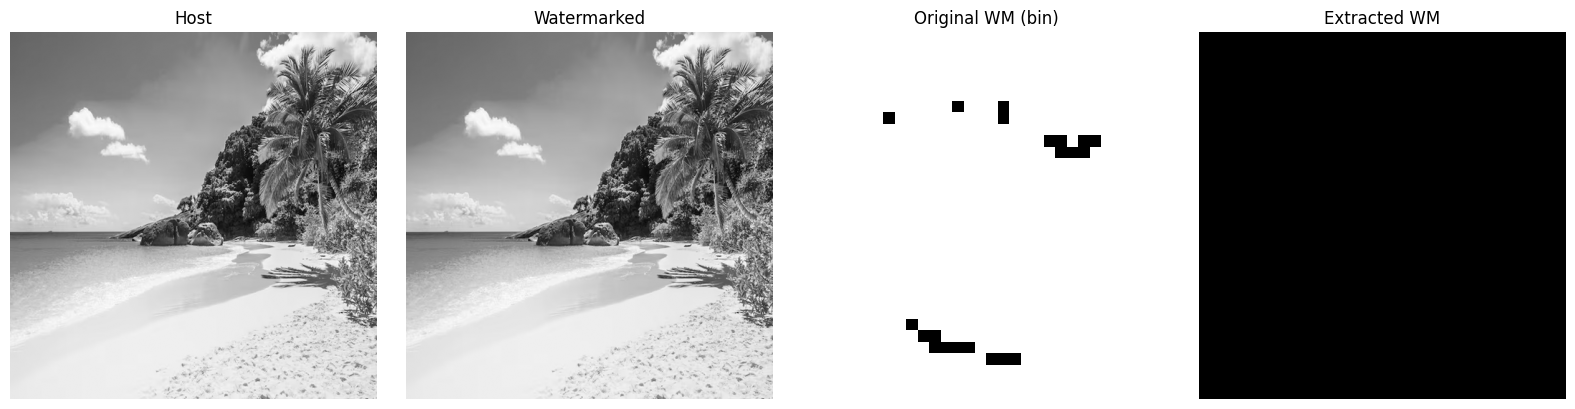

In [20]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(host, cmap='gray'); ax[0].set_title('Host')
ax[1].imshow(wm_img, cmap='gray'); ax[1].set_title('Watermarked')
ax[2].imshow(wm_original_bin, cmap='gray'); ax[2].set_title('Original WM (bin)')
ax[3].imshow(wm_extracted, cmap='gray'); ax[3].set_title('Extracted WM')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

In [21]:
alphas = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2]
print('alpha\tPSNR(dB)\trho')
for a in alphas:
    wm_img_a, _ = embed_watermark(
        host, wm_bits, alpha=a, seed=SEED, wavelet=WAVELET,
        subband_choice=SUBBAND_CHOICE, mid_pos=MID_POS
    )
    ex_bits_a = extract_watermark_bits(
        wm_img_a, capacity=EMBED_WM_SIZE * EMBED_WM_SIZE, seed=SEED,
        wavelet=WAVELET, subband_choice=SUBBAND_CHOICE, mid_pos=MID_POS
    )
    wm_extracted_a = bits_to_image(ex_bits_a, EMBED_WM_SIZE)
    print(f"{a:.3f}\t{psnr(host, wm_img_a):.4f}\t\t{rho(wm_original_bin, wm_extracted_a):.4f}")

alpha	PSNR(dB)	rho
0.005	118.2342		0.7277
0.010	112.2136		0.7284
0.020	106.1930		0.7325
0.030	102.6712		0.7331
0.050	98.2342		0.7385
0.100	92.2136		0.7546
0.200	86.1930		0.7786


In [22]:
# Constrained tuning: maximize rho while keeping PSNR near target
import warnings
warnings.filterwarnings('ignore')

TARGET_PSNR = 95.0
PSNR_TOL = 0.4

mid_pos_candidates = [
    [(0, 1), (1, 0), (1, 1)],
    [(0, 1), (1, 0), (1, 1), (0, 2), (2, 0)],
    [(0, 1), (1, 0), (1, 1), (0, 2), (2, 0), (1, 2), (2, 1)]
]
subband_candidates = ['HL2', 'HH2']
seed_candidates = [7, 21, 42, 77, 101, 12345, 2026, 4096]
alpha_candidates = np.linspace(0.008, 0.08, 37)

best = None
for sb in subband_candidates:
    for mid in mid_pos_candidates:
        for sd in seed_candidates:
            for a in alpha_candidates:
                wm_img_t, _ = embed_watermark(
                    host, wm_bits, alpha=float(a), seed=sd, wavelet=WAVELET,
                    subband_choice=sb, mid_pos=mid
                )
                p = psnr(host, wm_img_t)
                if abs(p - TARGET_PSNR) <= PSNR_TOL:
                    ex_bits_t = extract_watermark_bits(
                        wm_img_t, capacity=EMBED_WM_SIZE * EMBED_WM_SIZE, seed=sd,
                        wavelet=WAVELET, subband_choice=sb, mid_pos=mid
                    )
                    wm_extracted_t = bits_to_image(ex_bits_t, EMBED_WM_SIZE)
                    r = rho(wm_original_bin, wm_extracted_t)
                    cand = {
                        'rho': float(r),
                        'psnr': float(p),
                        'alpha': float(a),
                        'seed': sd,
                        'subband': sb,
                        'mid_pos': mid
                    }
                    if (best is None) or (cand['rho'] > best['rho']) or (cand['rho'] == best['rho'] and abs(cand['psnr'] - TARGET_PSNR) < abs(best['psnr'] - TARGET_PSNR)):
                        best = cand

if best is None:
    print('No combination found in the current search window. Increase PSNR_TOL or alpha range.')
else:
    print('Best under PSNR constraint:')
    print(best)

Best under PSNR constraint:
{'rho': 0.757865404233927, 'psnr': 95.06697076212572, 'alpha': 0.07200000000000001, 'seed': 12345, 'subband': 'HH2', 'mid_pos': [(0, 1), (1, 0), (1, 1), (0, 2), (2, 0), (1, 2), (2, 1)]}


In [23]:
# Local refinement around the best candidate to stay as close as possible to 95 dB
local_alphas = np.linspace(0.068, 0.078, 21)
best_local = None
for a in local_alphas:
    wm_img_l, _ = embed_watermark(
        host, wm_bits, alpha=float(a), seed=12345, wavelet=WAVELET,
        subband_choice='HH2', mid_pos=[(0, 1), (1, 0), (1, 1), (0, 2), (2, 0), (1, 2), (2, 1)]
    )
    p = psnr(host, wm_img_l)
    ex_bits_l = extract_watermark_bits(
        wm_img_l, capacity=EMBED_WM_SIZE * EMBED_WM_SIZE, seed=12345,
        wavelet=WAVELET, subband_choice='HH2', mid_pos=[(0, 1), (1, 0), (1, 1), (0, 2), (2, 0), (1, 2), (2, 1)]
    )
    wm_extracted_l = bits_to_image(ex_bits_l, EMBED_WM_SIZE)
    r = rho(wm_original_bin, wm_extracted_l)
    cand = {'alpha': float(a), 'psnr': float(p), 'rho': float(r)}
    if best_local is None:
        best_local = cand
    else:
        # prioritize closeness to 95 then higher rho
        if (abs(cand['psnr'] - 95.0) < abs(best_local['psnr'] - 95.0)) or (abs(cand['psnr'] - 95.0) == abs(best_local['psnr'] - 95.0) and cand['rho'] > best_local['rho']):
            best_local = cand

print('Best local:', best_local)

Best local: {'alpha': 0.07250000000000001, 'psnr': 95.00686055933096, 'rho': 0.757865404233927}


In [24]:
# Advanced experiments: PN strategy + mid-band set search under fixed PSNR
import itertools
from math import isfinite

def make_pn_pair(length, seed, mode='orthogonal_normal'):
    rng = np.random.default_rng(seed)
    if mode == 'independent_normal':
        pn0 = rng.standard_normal(length)
        pn1 = rng.standard_normal(length)
    elif mode == 'independent_rademacher':
        pn0 = rng.choice([-1.0, 1.0], size=length)
        pn1 = rng.choice([-1.0, 1.0], size=length)
    elif mode == 'orthogonal_rademacher':
        pn0 = rng.choice([-1.0, 1.0], size=length)
        pn1 = rng.choice([-1.0, 1.0], size=length)
        pn1 = pn1 - np.dot(pn1, pn0) / max(np.dot(pn0, pn0), 1e-12) * pn0
    elif mode == 'antipodal':
        pn0 = rng.standard_normal(length)
        pn1 = -pn0.copy()
    else:
        # orthogonal_normal (default)
        pn0 = rng.standard_normal(length)
        pn1 = rng.standard_normal(length)
        pn1 = pn1 - np.dot(pn1, pn0) / max(np.dot(pn0, pn0), 1e-12) * pn0

    pn0 = pn0 - np.mean(pn0)
    pn1 = pn1 - np.mean(pn1)
    n0 = np.linalg.norm(pn0)
    n1 = np.linalg.norm(pn1)
    if n0 == 0:
        pn0 = np.ones(length, dtype=np.float64)
        n0 = np.linalg.norm(pn0)
    if n1 == 0:
        alt = np.roll(pn0, 1)
        pn1 = alt - np.dot(alt, pn0) / max(np.dot(pn0, pn0), 1e-12) * pn0
        n1 = np.linalg.norm(pn1)
        if n1 == 0:
            pn1 = -pn0.copy()
            n1 = np.linalg.norm(pn1)
    pn0 = pn0 / n0
    pn1 = pn1 / n1
    return pn0.astype(np.float64), pn1.astype(np.float64)

def embed_watermark_exp(host, wm_bits, alpha, seed, wavelet, subband_choice, mid_pos, pn_mode):
    selected, ctx = _select_subband_level2(host, wavelet=wavelet, subband_choice=subband_choice)
    h, w = selected.shape
    capacity = (h // 4) * (w // 4)
    bits = wm_bits[:capacity].copy()
    if bits.size < capacity:
        bits = np.pad(bits, (0, capacity - bits.size), mode='constant')

    pn0, pn1 = make_pn_pair(len(mid_pos), seed, mode=pn_mode)

    idx = 0
    mod = selected.copy()
    for r in range(0, h, 4):
        for c in range(0, w, 4):
            block = mod[r:r+4, c:c+4]
            B = dct2(block)
            X = np.array([B[i, j] for (i, j) in mid_pos], dtype=np.float64)
            Xp = X + alpha * (pn0 if bits[idx] == 0 else pn1)
            for k, (i, j) in enumerate(mid_pos):
                B[i, j] = Xp[k]
            mod[r:r+4, c:c+4] = idct2(B)
            idx += 1

    host_wm = _reconstruct_from_subband(mod, ctx)
    host_wm = np.clip(host_wm, 0, 255)
    return host_wm

def extract_watermark_bits_exp(watermarked, capacity, seed, wavelet, subband_choice, mid_pos, pn_mode):
    selected, _ = _select_subband_level2(watermarked, wavelet=wavelet, subband_choice=subband_choice)
    h, w = selected.shape
    pn0, pn1 = make_pn_pair(len(mid_pos), seed, mode=pn_mode)

    bits_out = []
    for r in range(0, h, 4):
        for c in range(0, w, 4):
            if len(bits_out) >= capacity:
                break
            B = dct2(selected[r:r+4, c:c+4])
            X = np.array([B[i, j] for (i, j) in mid_pos], dtype=np.float64)
            b = 0 if corr(X, pn0) > corr(X, pn1) else 1
            bits_out.append(b)
        if len(bits_out) >= capacity:
            break
    return np.array(bits_out, dtype=np.uint8)

def calibrate_alpha_for_psnr(target_psnr, host, wm_bits, seed, wavelet, subband_choice, mid_pos, pn_mode, lo=1e-4, hi=0.5, iters=16):
    # Increase upper bound until PSNR falls below target (monotonic in practice here).
    wm_try = embed_watermark_exp(host, wm_bits, alpha=hi, seed=seed, wavelet=wavelet, subband_choice=subband_choice, mid_pos=mid_pos, pn_mode=pn_mode)
    p_hi = psnr(host, wm_try)
    grow = 0
    while p_hi > target_psnr and hi < 10 and grow < 12:
        hi *= 2.0
        wm_try = embed_watermark_exp(host, wm_bits, alpha=hi, seed=seed, wavelet=wavelet, subband_choice=subband_choice, mid_pos=mid_pos, pn_mode=pn_mode)
        p_hi = psnr(host, wm_try)
        grow += 1

    best = None
    for _ in range(iters):
        mid_a = (lo + hi) / 2.0
        wm_mid = embed_watermark_exp(host, wm_bits, alpha=mid_a, seed=seed, wavelet=wavelet, subband_choice=subband_choice, mid_pos=mid_pos, pn_mode=pn_mode)
        p_mid = psnr(host, wm_mid)
        best = (mid_a, p_mid)
        if p_mid > target_psnr:
            lo = mid_a
        else:
            hi = mid_a

    return best  # (alpha, psnr)

In [25]:
# Run experiment grid and rank by rho (PSNR locked near target)
TARGET_PSNR = 95.0
PSNR_BAND = 0.20

mid_pos_library = [
    [(0, 1), (1, 0), (1, 1)],
    [(0, 1), (1, 0), (1, 1), (0, 2), (2, 0)],
    [(0, 1), (1, 0), (1, 1), (0, 2), (2, 0), (1, 2), (2, 1)],
    [(0, 1), (1, 0), (1, 1), (2, 0), (1, 2), (2, 1)],
    [(0, 2), (2, 0), (1, 1), (1, 2), (2, 1)]
]
pn_modes = ['orthogonal_normal', 'independent_normal', 'orthogonal_rademacher', 'independent_rademacher', 'antipodal']
subbands = ['HH2', 'HL2']
seeds = [11, 21, 42, 77, 101, 333, 777, 12345, 2026]

capacity = EMBED_WM_SIZE * EMBED_WM_SIZE
exp_results = []

for sb, mid_pos, pn_mode, sd in itertools.product(subbands, mid_pos_library, pn_modes, seeds):
    alpha_star, psnr_star = calibrate_alpha_for_psnr(
        TARGET_PSNR, host, wm_bits, sd, WAVELET, sb, mid_pos, pn_mode, lo=1e-4, hi=0.5, iters=14
    )
    if abs(psnr_star - TARGET_PSNR) > PSNR_BAND:
        continue

    wm_img_e = embed_watermark_exp(
        host, wm_bits, alpha=alpha_star, seed=sd, wavelet=WAVELET,
        subband_choice=sb, mid_pos=mid_pos, pn_mode=pn_mode
    )
    ex_bits_e = extract_watermark_bits_exp(
        wm_img_e, capacity=capacity, seed=sd, wavelet=WAVELET,
        subband_choice=sb, mid_pos=mid_pos, pn_mode=pn_mode
    )
    wm_extracted_e = bits_to_image(ex_bits_e, EMBED_WM_SIZE)
    rho_e = rho(wm_original_bin, wm_extracted_e)

    exp_results.append({
        'rho': float(rho_e),
        'psnr': float(psnr_star),
        'alpha': float(alpha_star),
        'seed': int(sd),
        'subband': sb,
        'pn_mode': pn_mode,
        'mid_pos': mid_pos,
        'mid_len': len(mid_pos)
    })

if not exp_results:
    print('No candidates satisfied the PSNR band. Try increasing PSNR_BAND to 0.3 or 0.4.')
else:
    exp_results = sorted(exp_results, key=lambda x: (x['rho'], -abs(x['psnr'] - TARGET_PSNR)), reverse=True)
    best_exp = exp_results[0]
    print('Best candidate:')
    print(best_exp)
    print('\nTop 5:')
    for i, row in enumerate(exp_results[:5], start=1):
        print(i, row)

Best candidate:
{'rho': 0.9896929763820698, 'psnr': 94.99933831017897, 'alpha': 0.07256475219726562, 'seed': 101, 'subband': 'HH2', 'pn_mode': 'independent_rademacher', 'mid_pos': [(0, 1), (1, 0), (1, 1), (2, 0), (1, 2), (2, 1)], 'mid_len': 6}

Top 5:
1 {'rho': 0.9896929763820698, 'psnr': 94.99933831017897, 'alpha': 0.07256475219726562, 'seed': 101, 'subband': 'HH2', 'pn_mode': 'independent_rademacher', 'mid_pos': [(0, 1), (1, 0), (1, 1), (2, 0), (1, 2), (2, 1)], 'mid_len': 6}
2 {'rho': 0.9896929763820698, 'psnr': 94.99927952392598, 'alpha': 0.07256475219726562, 'seed': 2026, 'subband': 'HL2', 'pn_mode': 'independent_rademacher', 'mid_pos': [(0, 1), (1, 0), (1, 1)], 'mid_len': 3}
3 {'rho': 0.9896929763820698, 'psnr': 94.99916215001937, 'alpha': 0.07256475219726562, 'seed': 101, 'subband': 'HL2', 'pn_mode': 'independent_rademacher', 'mid_pos': [(0, 1), (1, 0), (1, 1), (2, 0), (1, 2), (2, 1)], 'mid_len': 6}
4 {'rho': 0.9896929763820698, 'psnr': 94.9991006594309, 'alpha': 0.07256475219726

In [26]:
# Diagnose WM mismatch at bit level
orig_bits = (wm_original_bin.flatten() > 127).astype(np.uint8)
ext_bits = (wm_extracted.flatten() > 127).astype(np.uint8)

same = np.mean(orig_bits == ext_bits)
ber = np.mean(orig_bits != ext_bits)
ones_orig = int(orig_bits.sum())
ones_ext = int(ext_bits.sum())
ones_ext_inv = int((1 - ext_bits).sum())

# Try global inversion ambiguity check (0/1 label swap)
ber_inv = np.mean(orig_bits != (1 - ext_bits))
same_inv = np.mean(orig_bits == (1 - ext_bits))

print('Original ones:', ones_orig, 'out of', orig_bits.size)
print('Extracted ones:', ones_ext, 'out of', ext_bits.size)
print('Bit accuracy:', round(float(same), 4), 'BER:', round(float(ber), 4))
print('If inverted -> Bit accuracy:', round(float(same_inv), 4), 'BER:', round(float(ber_inv), 4))

Original ones: 1003 out of 1024
Extracted ones: 1024 out of 1024
Bit accuracy: 0.9795 BER: 0.0205
If inverted -> Bit accuracy: 0.0205 BER: 0.9795
